## Incident Prediction

We want to predict if the incident will occur within the next H time steps given the previous W observations?

It's a binary classfication problem with temporal relationship.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, roc_auc_score

np.random.seed(42)

First, we generate synthetic data. There will be 3 correlated metrics and incident occurs when etric_1 exceeds a threshold or a sudden anomaly (spike) occurs.


In [2]:
T = 10000 # total time steps
t = np.arange(T)

metric_1 = np.sin(0.02 * t) + 0.1 * np.random.randn(T)
metric_2 = np.cos(0.015 * t) + 0.1 * np.random.randn(T)
metric_3 = 0.5 * metric_1 + 0.3 * metric_2 + 0.1 * np.random.randn(T)

# inject anomalies
incident = np.zeros(T)

for i in range(200, T, 500):
    metric_1[i:i+5] += 3
    incident[i:i+5] = 1

data = pd.DataFrame({
    "m1": metric_1,
    "m2": metric_2,
    "m3": metric_3,
    "incident": incident
})

It's usually good to start with data normalisation:

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features = scaler.fit_transform(data[["m1","m2","m3"]])

data_scaled = pd.DataFrame(features, columns=["m1","m2","m3"])
data_scaled["incident"] = data["incident"]


Step 2: Sliding window dataset

In [4]:
W = 30 # history window
H = 10 # prediction horizon

result_per_window = []

X = []
y = []

for t in range(W, T - H):
    window = data_scaled[["m1", "m2", "m3"]].iloc[t-W:t].values
    future_incident = data_scaled["incident"].iloc[t:t+H].max()

    X.append(window)
    y.append(future_incident)

X = np.array(X)
y = np.array(y)

In [5]:
print("Incident ratio:", y.mean())

Incident ratio: 0.028112449799196786


THere's some class Imbalance, so it's better to use weighted loss during training...

Step 3: Train/Valid/Test Split (Time-Aware)

In [6]:
train_end = int(0.7 * len(X))
val_end = int(0.85 * len(X))

X_train = X[:train_end]
X_val = X[train_end:val_end]
X_test = X[val_end:]

y_train = y[:train_end]
y_val = y[train_end:val_end]
y_test = y[val_end:]


Step 4: LSTM model

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=64, shuffle=False)

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=32):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return self.sigmoid(out)

In [9]:
model = LSTMModel().to(device)
pos_weight = torch.tensor([(len(y_train) - y_train.sum()) / y_train.sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Step 5: Training

In [10]:
for epoch in range(50):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)

        preds = model(xb)
        loss = criterion(preds, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

Epoch 0, Loss: 153.7745
Epoch 1, Loss: 149.9434
Epoch 2, Loss: 145.0825
Epoch 3, Loss: 142.3547
Epoch 4, Loss: 140.4720
Epoch 5, Loss: 139.2004
Epoch 6, Loss: 138.3202
Epoch 7, Loss: 137.6781
Epoch 8, Loss: 137.2007
Epoch 9, Loss: 136.8442
Epoch 10, Loss: 136.5912
Epoch 11, Loss: 136.4115
Epoch 12, Loss: 136.2346
Epoch 13, Loss: 136.1513
Epoch 14, Loss: 135.9274
Epoch 15, Loss: 136.0413
Epoch 16, Loss: 135.8005
Epoch 17, Loss: 135.8357
Epoch 18, Loss: 135.7385
Epoch 19, Loss: 135.9246
Epoch 20, Loss: 135.6735
Epoch 21, Loss: 135.6066
Epoch 22, Loss: 135.3531
Epoch 23, Loss: 135.9035
Epoch 24, Loss: 135.3164
Epoch 25, Loss: 134.8348
Epoch 26, Loss: 136.8984
Epoch 27, Loss: 134.8322
Epoch 28, Loss: 134.3745
Epoch 29, Loss: 133.9778
Epoch 30, Loss: 134.0575
Epoch 31, Loss: 134.6633
Epoch 32, Loss: 135.6453
Epoch 33, Loss: 134.0275
Epoch 34, Loss: 133.3316
Epoch 35, Loss: 132.7381
Epoch 36, Loss: 132.4628
Epoch 37, Loss: 132.3915
Epoch 38, Loss: 131.5574
Epoch 39, Loss: 131.7819
Epoch 40, 

Step 6: Evaluation

In [11]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1,0.9,50)
best_t = 0
best_f1 = 0

model.eval() # Ensure model is in evaluation mode
with torch.no_grad():
    # Generate probabilities for the validation set
    X_val_t_device = X_val_t.to(device) # Move validation features to device
    probs_val = model(X_val_t_device).cpu().numpy().flatten() # Calculate probabilities

for t in thresholds:
    preds = (probs_val > t).astype(int) # Use probs_val for predictions
    f1 = f1_score(y_val, preds) # y_val and preds now consistent length

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)

Best threshold: 0.5081632653061224


In [12]:
model.eval()
with torch.no_grad():
    # Convert X_test to a tensor and move to device
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    # Generate probabilities for the test set
    probs = model(X_test_t).cpu().numpy().flatten()

# Use the best threshold determined from the validation set for test set predictions
preds = (probs > best_t).astype(int)

print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

         0.0       0.98      0.93      0.95      1452
         1.0       0.12      0.36      0.18        42

    accuracy                           0.91      1494
   macro avg       0.55      0.64      0.57      1494
weighted avg       0.96      0.91      0.93      1494

ROC-AUC: 0.7319788797061524


Data visualisation:

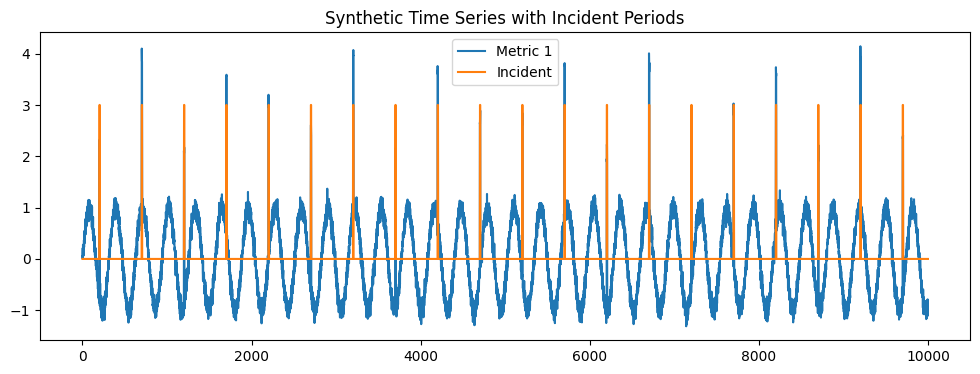

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(data["m1"], label="Metric 1")
plt.plot(data["incident"] * 3, label="Incident")
plt.legend()
plt.title("Synthetic Time Series with Incident Periods")
plt.show()


In [14]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc

preds = (probs > best_t).astype(int)

print(confusion_matrix(y_test, preds))

[[1344  108]
 [  27   15]]


In [15]:
precision, recall, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)


PR-AUC: 0.2737936751979002
